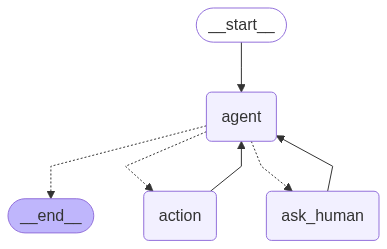

In [ ]:
# Set up the state
import os

from dotenv import load_dotenv
from IPython.display import Image

# Set up the tool
# We will have one real tool - a search tool
# We'll also have one "fake" tool - a "ask_human" tool
# Here we define any ACTUAL tools
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.types import Command, interrupt
from pydantic import BaseModel

load_dotenv()


@tool
def search(query: str):
    """Call to surf the web."""
    # This is a placeholder for the actual implementation
    # Don't let the LLM know this though 😊
    return f"I looked up: {query}. Result: It's sunny in San Francisco, but you better look out if you're a Gemini 😈."


tools = [search]
tool_node = ToolNode(tools)

# Set up the model


model = ChatOpenAI(model="gpt-5-nano", api_key=os.getenv("OPENAI_API_KEY"))


# We are going "bind" all tools to the model
# We have the ACTUAL tools from above, but we also need a mock tool to ask a human
# Since `bind_tools` takes in tools but also just tool definitions,
# We can define a tool definition for `ask_human`
class AskHuman(BaseModel):
    """Ask the human a question"""

    question: str


model = model.bind_tools(tools + [AskHuman])

# Define nodes and conditional edges


# Define the function that determines whether to continue or not
def should_continue(state):
    messages = state["messages"]
    last_message = messages[-1]
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return END
    # If tool call is asking Human, we return that node
    # You could also add logic here to let some system know that there's something that requires Human input
    # For example, send a slack message, etc
    elif last_message.tool_calls[0]["name"] == "AskHuman":
        return "ask_human"
    # Otherwise if there is, we continue
    else:
        return "action"


# Define the function that calls the model
def call_model(state):
    messages = state["messages"]
    response = model.invoke(messages)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


# We define a fake node to ask the human
def ask_human(state):
    # 1. 도구 호출 ID를 추출하여 나중에 응답을 연결할 수 있도록 함
    tool_call_id = state["messages"][-1].tool_calls[0]["id"]

    #  한마디로: 나중에 사용자의 답변을 어떤 질문에 대한 응답인지 알려주기 위해, LLM이 생성한 '질문
    #   요청'의 고유한 ID(송장 번호)를 미리 저장해두는 코드입니다.

    #   코드 상세 분석:

    #    * state["messages"]: 그래프의 전체 대화 기록(메시지 리스트)에 접근합니다.
    #    * [-1]: 리스트의 가장 마지막 메시지를 가져옵니다. ask_human 노드는 항상 LLM(agent) 노드 바로
    #      다음에 호출되므로, 이 마지막 메시지는 LLM이 방금 생성한 AIMessage입니다.
    #    * .tool_calls: 해당 AIMessage에 포함된 Tool Call 목록을 가져옵니다. LLM은 한 번에 여러 도구를
    #      호출할 수 있어 목록 형태입니다.
    #    * [0]: Tool Call 목록에서 첫 번째 Tool Call을 선택합니다. (이 예제에서는 항상 하나만
    #      호출합니다.)
    #    * ["id"]: 해당 Tool Call의 고유 ID 값(예: call_TRpuVEAxGlrIrCwYpglMGCBT)을 최종적으로
    #      가져옵니다.

    #   🤔 왜 이 ID가 필요한가요?

    #   이 ID는 '택배 송장 번호' 와 같다고 생각하시면 완벽합니다.

    #    1. 질문 발송: LLM이 "어디에 계신가요?"라는 '질문' 택배를 보낼 때, tool_call_id라는 고유한 송장
    #       번호를 붙여서 보냅니다.
    #    2. 송장 번호 기록: ask_human 노드는 이 송장 번호를 tool_call_id 변수에 잘 기록해 둡니다.
    #    3. 답변 회신: 잠시 후, 사용자가 "서울입니다"라는 '답변'을 보내면, 우리는 이 답변을 그냥 보내는
    #       게 아니라 기록해 두었던 송장 번호표(`tool_call_id`)를 붙여서 ToolMessage라는 상자에 담아
    #       보냅니다.
    #    4. 정확한 처리: 덕분에 LLM은 "아, 이 답변은 아까 내가 보냈던 그 질문 택배에 대한 회신이구나!"
    #       하고 정확하게 인지하고 다음 작업을 처리할 수 있습니다.

    #   만약 이 ID가 없다면, LLM은 뜬금없이 "서울입니다"라는 메시지를 받고 이게 무엇에 대한 답변인지
    #   알 수 없어 혼란에 빠지게 됩니다.

    # 2. LLM이 생성한 도구 호출의 인수를 AskHuman 모델로 검증하고 파싱
    ask = AskHuman.model_validate(state["messages"][-1].tool_calls[0]["args"])

    #   한마디로: LLM이 보낸 요청의 내용물(args)이 우리가 약속한 AskHuman 모델(질문은 question이라는
    #   필드에 담을 것) 형식에 맞는지 검증하고, 파이썬에서 다루기 쉬운 객체로 변환하는 코드입니다.

    #   코드 상세 분석:

    #    * state["messages"][-1].tool_calls[0]: 위와 동일하게, LLM이 생성한 첫 번째 Tool Call에
    #      접근합니다.
    #    * ["args"]: Tool Call의 내용물, 즉 인자(arguments)를 가져옵니다. 이 값은 보통 {'question':
    #      '어디에 계신가요?'}와 같은 딕셔너리 형태입니다.
    #    * AskHuman.model_validate(...): Pydantic 모델의 핵심 기능입니다.
    #        * ["args"]로 받은 딕셔너리가 AskHuman 클래스에 정의된 형식(예: question 필드가 있고, 그
    #          값은 문자열)을 만족하는지 검사합니다.
    #        * 만약 형식이 다르면 에러를 발생시켜 잘못된 데이터로 시스템이 오작동하는 것을 막습니다.
    #        * 검증에 통과하면, 단순 딕셔너리를 AskHuman 클래스의 인스턴스(객체)로 변환하여 ask 변수에
    #          저장합니다.

    #   🤔 왜 이 과정이 필요한가요?

    #    1. 안정성 (Safety): LLM이 항상 완벽하지는 않습니다. 만약 LLM이 실수로 약속된 형식과 다른
    #       {'query': '어디?'} 같은 데이터를 보내더라도, model_validate 단계에서 에러가 발생하여 미리
    #       문제를 잡아낼 수 있습니다.
    #    2. 편의성 (Convenience): 검증이 끝나면 ask는 단순 딕셔너리가 아닌 객체가 됩니다. 따라서
    #       ask['question']처럼 키 이름으로 접근하는 대신, ask.question처럼 속성으로 깔끔하게 접근할 수
    #       있습니다. 이는 오타를 줄여주고, 코드 자동 완성과 같은 개발 도구의 도움을 받기에도 좋습니다.

    # 3. 사용자에게 질문을 표시하고 응답을 기다림 (워크플로우 중단)
    location = interrupt(ask.question)

    # 4. 사용자의 응답을 도구 메시지 형태로 포맷팅
    # - tool_call_id: 원래 도구 호출과 연결
    # - type: "tool" (도구 응답임을 나타냄)
    # - content: 사용자가 입력한 응답 내용
    tool_message = [{"tool_call_id": tool_call_id, "type": "tool", "content": location}]

    # 5. 메시지 상태를 업데이트하여 워크플로우에 반환
    return {"messages": tool_message}


# Build the graph


# Define a new graph
workflow = StateGraph(MessagesState)

# Define the three nodes we will cycle between
workflow.add_node("agent", call_model)
workflow.add_node("action", tool_node)
workflow.add_node("ask_human", ask_human)

# Set the entrypoint as `agent`
# This means that this node is the first one called
workflow.add_edge(START, "agent")

# We now add a conditional edge
workflow.add_conditional_edges(
    # First, we define the start node. We use `agent`.
    # This means these are the edges taken after the `agent` node is called.
    "agent",
    # Next, we pass in the function that will determine which node is called next.
    should_continue,
    path_map=["ask_human", "action", END],
)

# We now add a normal edge from `tools` to `agent`.
# This means that after `tools` is called, `agent` node is called next.
workflow.add_edge("action", "agent")

# After we get back the human response, we go back to the agent
workflow.add_edge("ask_human", "agent")

# Set up memory


memory = InMemorySaver()

# Finally, we compile it!
# This compiles it into a LangChain Runnable,
# meaning you can use it as you would any other runnable
app = workflow.compile(checkpointer=memory)

display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
config = {"configurable": {"thread_id": "2"}}
for event in app.stream(
    {
        "messages": [
            (
                "user",
                "Ask the user where they are, then look up the weather there",
            )
        ]
    },
    config,
    stream_mode="values",
):
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

Ask the user where they are, then look up the weather there
================================== Ai Message ==================================
Tool Calls:
  AskHuman (call_30R27b8khs3NNJpnAP6agPcX)
 Call ID: call_30R27b8khs3NNJpnAP6agPcX
  Args:
    question: Where are you right now? Please tell me your city and country (or your exact coordinates if you prefer).


In [37]:
# 이 코드는 현재 워크플로우의 상태(state)를 가져온 뒤, 그 상태에서 다음(next) 상태로 진행할 수 있는 메서드나 속성을 호출하는 부분입니다.
# 즉, app.get_state(config)는 주어진 config(여기서는 thread_id 등)를 바탕으로 현재 LangGraph 워크플로우의 상태 객체를 반환합니다.
# 그리고 .next는 그 상태에서 다음 단계로 넘어가는 동작(혹은 다음 상태에 대한 참조)을 의미합니다.
# 실제로 이 코드를 실행하면, 현재 워크플로우의 상태에서 다음 단계로 진행하거나, 다음 상태에 대한 정보를 얻을 수 있습니다.
next_node = app.get_state(config).next
interrupts_node = app.get_state(config).interrupts
parent_config = app.get_state(config).parent_config
state_task = app.get_state(config).tasks
metadata = app.get_state(config).metadata
state_values = app.get_state(config).values

print(next_node)
print(interrupts_node[0])
print(parent_config)
print(state_task)
print(metadata)
print(state_values)

('ask_human',)
Interrupt(value='Where are you right now? Please tell me your city and country (or your exact coordinates if you prefer).', resumable=True, ns=['ask_human:9b8cd274-1d8c-4760-2117-3e41a1db09eb'])
{'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f080f80-29e1-643a-8000-b97baf0d2ace'}}
(PregelTask(id='9b8cd274-1d8c-4760-2117-3e41a1db09eb', name='ask_human', path=('__pregel_pull', 'ask_human'), error=None, interrupts=(Interrupt(value='Where are you right now? Please tell me your city and country (or your exact coordinates if you prefer).', resumable=True, ns=['ask_human:9b8cd274-1d8c-4760-2117-3e41a1db09eb']),), state=None, result=None),)
{'source': 'loop', 'step': 1, 'parents': {}}
{'messages': [HumanMessage(content='Ask the user where they are, then look up the weather there', additional_kwargs={}, response_metadata={}, id='3db4d5d9-50e4-4fcd-883c-db60f5b0dc10'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_30R27b8khs3NNJpn

In [12]:
for event in app.stream(
    Command(resume="san francisco"),
    config,
    stream_mode="values",
):
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: search

I looked up: San Francisco current weather. Result: It's sunny in San Francisco, but you better look out if you're a Gemini 😈.
================================== Ai Message ==================================
Tool Calls:
  search (call_jcsC4MvwwSnZjAM1TPCTVRSt)
 Call ID: call_jcsC4MvwwSnZjAM1TPCTVRSt
  Args:
    query: San Francisco weather today
================================= Tool Message =================================
Name: search

I looked up: San Francisco weather today. Result: It's sunny in San Francisco, but you better look out if you're a Gemini 😈.
================================== Ai Message ==================================
Tool Calls:
  search (call_lFBEFx4c9ScsNQSRjUkxWEMv)
 Call ID: call_lFBEFx4c9ScsNQSRjUkxWEMv
  Args:
    query: San Francisco current weather
================================= Tool Message =================================
Name: search

I looked up: San Fr

In [ ]:
if "messages" in event:
    for message in event["messages"]:
        print(message["content"])

TypeError: 'HumanMessage' object is not subscriptable